In [103]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt

In [104]:
# 1. Load and Preprocess the Data
def load_data(file_path):
    df = pd.read_csv(file_path)
    return df['Close'].values  # Use the 'Close' price for prediction

In [105]:
# 2. Prepare the Dataset for LSTM
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step):
        X.append(data[i:(i + time_step)])
        y.append(data[i + time_step])
    return np.array(X), np.array(y)

In [106]:
# Load Data
file_path = 'GOOG.csv'  # Path to the dataset in Colab or Jupyter home directory
data = load_data(file_path)

In [107]:
# Normalize the Data
scaler = MinMaxScaler(feature_range=(0, 1))
data = scaler.fit_transform(data.reshape(-1, 1)).reshape(-1)

In [108]:

# Create the Dataset
time_step = 60  # Using 60 days of data to predict the next day's price
X, y = create_dataset(data, time_step)

In [109]:
# Reshape for LSTM input [samples, time steps, features]
X = X.reshape(X.shape[0], X.shape[1], 1)

In [110]:
# Split the Data into Training and Testing Sets (80% train, 20% test)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [111]:
# 3. Define the LSTM Model
model = Sequential()

# --- Students: Modify the number of LSTM layers and units to experiment with model complexity ---
model.add(LSTM(units=60, return_sequences=True, input_shape=(time_step, 1)))  # <-- Experiment with 'units'
model.add(Dropout(0.4))  # Experiment with dropout for regularization

model.add(LSTM(units=90, return_sequences=True))  # <-- Add another LSTM layer
model.add(LSTM(units=90, return_sequences=False))  # <-- Add another LSTM layer
model.add(Dropout(0.3))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mean_absolute_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [112]:
# 4. Train the Model

model.fit(X_train, y_train, epochs=40, batch_size=50, verbose=1)  # <-- Experiment with 'epochs' and 'batch_size'

Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 189ms/step - loss: 0.4497
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 279ms/step - loss: 0.1921
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 263ms/step - loss: 0.2448
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: 0.2083
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 138ms/step - loss: 0.1386
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: 0.1340
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.1615
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 146ms/step - loss: 0.1939
Epoch 9/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step - loss: 0.1296
Epoch 10/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - loss: 0.1541
Epoch 11/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.1229
Epoch 12/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.1342
Epoch 13/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.1388
Epoch 14/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step - loss: 0.1226
Epoch 15/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.1232
Epoch 16/40
4/4 ━━━

In [113]:
# 5. Predict on the Test Data
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 441ms/step


In [114]:
# Inverse transform to get the original scale
y_pred = scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(-1)
y_test = scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

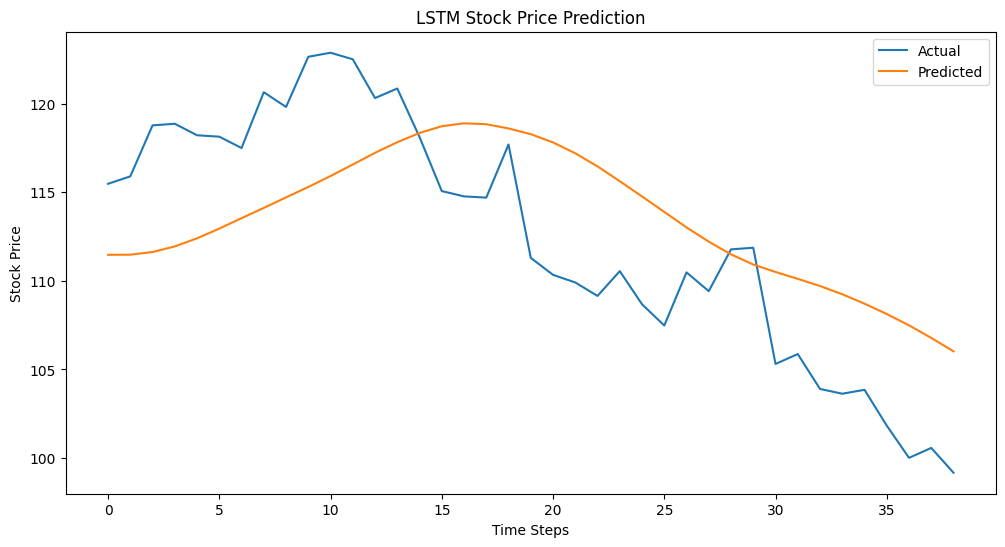

In [115]:
# 6. Plot the Results
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel('Time Steps')
plt.ylabel('Stock Price')
plt.title('LSTM Stock Price Prediction')
plt.legend()
plt.show()



1) Normalization makes the input values suitable for LSTM training (faster and more stable learning)

2) Dropout prevents overfitting and helps the model generalize better.
3) Get Good Model Performance and
 Get Low Prediction Error

In [116]:
model.save("IT22354938Q2.h5")   # HDF5 format
